In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
#Load the data
df = pd.read_csv(
    "../data/raw/WHO-COVID-19-global-daily-data.csv"
)

df["Date_reported"] = pd.to_datetime(
    df["Date_reported"]
)

df["year"] = df["Date_reported"].dt.year

print(df.shape)

(556560, 9)


In [6]:
#create nigeria subset
nigeria = df[
    df["Country"] == "Nigeria"
].copy()

nigeria_2020_2021 = nigeria[
    nigeria["year"].isin([2020, 2021])
].copy()

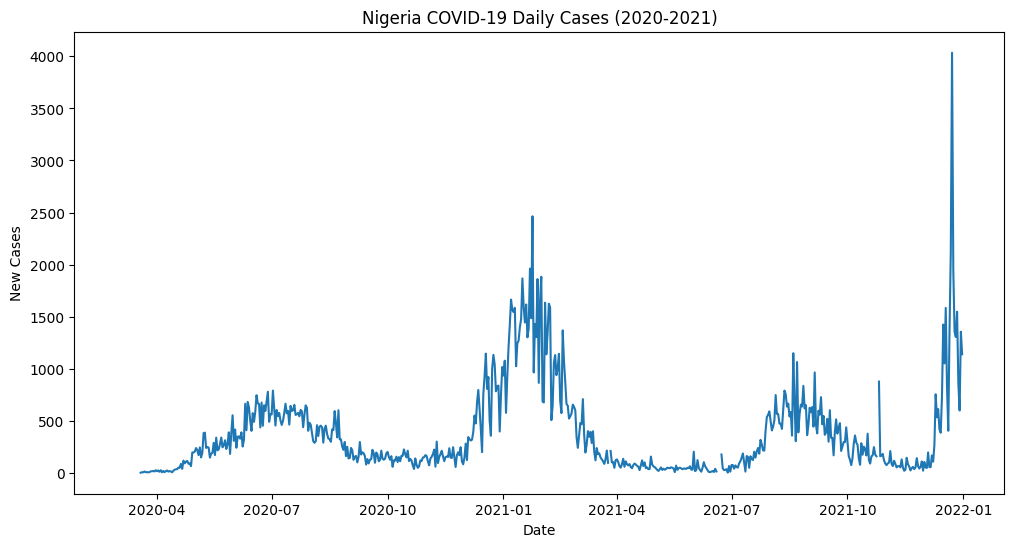

In [7]:
#create a quick epidemic curve
plt.figure(figsize = (12,6))

plt.plot(
    nigeria_2020_2021["Date_reported"],
    nigeria_2020_2021["New_cases"]
)

plt.title(
    "Nigeria COVID-19 Daily Cases (2020-2021)"
)

plt.xlabel("Date")
plt.ylabel("New Cases")
plt.show()

## Initial Epidemic Curve Observations

- Multiple COVID-19 waves are visible in Nigeria during 2020–2021.
- A moderate wave occurred in mid-2020.
- A larger wave occurred between December 2020 and February 2021.
- Another wave is visible during mid-2021.
- A sharp increase in reported cases occurs in late 2021.
- Further investigation is required before attributing waves to specific variants or public-health events.

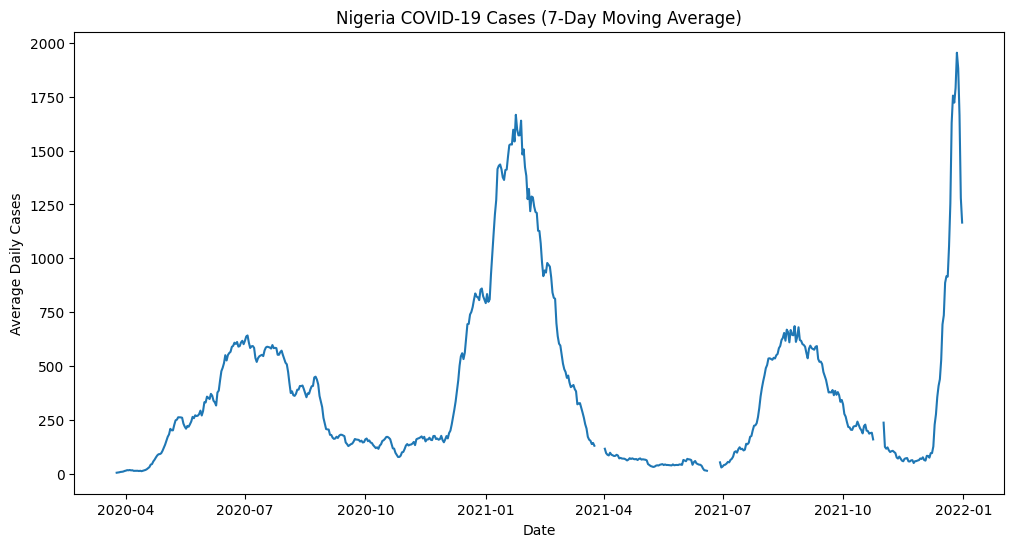

In [8]:
# Smoothing using 7-day moving aveage
nigeria_2020_2021["cases_ma7"] = (
    nigeria_2020_2021["New_cases"]
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    nigeria_2020_2021["Date_reported"],
    nigeria_2020_2021["cases_ma7"]
)

plt.title(
    "Nigeria COVID-19 Cases (7-Day Moving Average)"
)

plt.xlabel("Date")
plt.ylabel("Average Daily Cases")

plt.show()

## 7-Day Moving Average Observations

- Four major COVID-19 waves are visible during 2020–2021.
- The largest sustained wave occurred around January 2021.
- Another large wave begins in December 2021.
- The moving average reveals epidemic patterns more clearly than raw daily counts.
- Additional contextual information is required before attributing peaks to specific variants or policy changes.

In [10]:
monthly_cases = (
    nigeria_2020_2021
    .groupby(
        pd.Grouper(
            key="Date_reported",
            freq="ME"
        )
    )["New_cases"]
    .sum()
    .reset_index()
)

monthly_cases.head()

,Date_reported,New_cases
0,2020-01-31,0.0
1,2020-02-29,1.0
2,2020-03-31,135.0
3,2020-04-30,1592.0
4,2020-05-31,8127.0


In [11]:
monthly_cases.sort_values(
    "New_cases",
    ascending=False
).head(10)

,Date_reported,New_cases
12,2021-01-31,43981.0
23,2021-12-31,27400.0
13,2021-02-28,24860.0
11,2020-12-31,19164.0
19,2021-08-31,18394.0
6,2020-07-31,17556.0
5,2020-06-30,15278.0
20,2021-09-30,13679.0
7,2020-08-31,11176.0
4,2020-05-31,8127.0


## Monthly Burden Findings

- January 2021 recorded the highest monthly case burden (43,981 cases).
- December 2021 recorded the second highest monthly burden (27,400 cases).
- February 2021 recorded the third highest monthly burden (24,860 cases).
- The January 2021 wave was both visually prominent and quantitatively the largest observed wave during the study period.